# Notebook 02: Validation NLP & Analyse Lexicale
## MIMIC-IV/ED

---

**Entrée** : `data/processed/cohort_raw.csv` (produit par NB01; contient déjà `cleaned_complaint`)

**Rôle de ce notebook** :
- Vérifier la qualité du prétraitement NLP effectué dans NB01
- Analyses lexicales : top termes, wordclouds, TF-IDF discriminant
- Sauvegarder `cohort_nlp.csv` (identique à `cohort_raw.csv`, renommé pour une meilleure compréhension)

**Sortie** : `data/processed/cohort_nlp.csv`


---
## 1. Configuration & Imports

In [1]:
import os
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt         
import seaborn as sns                     

warnings.filterwarnings("ignore")

#  Chemins projet — bloc unifié, identique dans NB01
def _racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Racine = 1er dossier (courant ou parent) contenant un dossier repere."""
    for _p in (Path.cwd(), *Path.cwd().parents):
        if any((_p / _m).is_dir() for _m in reperes):
            return _p
    return Path.cwd()

ROOT_DIR   = _racine_projet()
BASE       = ROOT_DIR / "data"
OUT_DIR    = ROOT_DIR / "data" / "processed"
SPLIT_DIR  = OUT_DIR / "splits"
FIG_DIR    = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR  = RESULT_DIR / "tables"
MODEL_DIR  = ROOT_DIR / "models"
for _d in (OUT_DIR, SPLIT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# Style graphiques cohérent
sns.set_theme(style="whitegrid")
BLEU  = "#2E5F8A"
ROUGE = "#C0392B"

print("Imports OK")

Imports OK


---
## 2. Chargement de la cohorte (NB01)

In [2]:
# Chargement depuis cohort_raw.csv (produit par NB01) 
# Chemins déjà définis dans la cellule de configuration (bloc unifié).

input_path = OUT_DIR / 'cohort_raw.csv'

if not input_path.exists():
    raise FileNotFoundError(
        f'Fichier introuvable : {input_path}\n'
        'Exécuter d\'abord NB01 pour générer cohort_raw.csv'
    )

df = pd.read_csv(input_path, low_memory=False)
print(f'Cohorte chargée : {len(df):,} séjours × {df.shape[1]} colonnes')
print(f'Colonnes : {list(df.columns)}')

TARGET = 'target'
assert TARGET in df.columns, f'Colonne cible "{TARGET}" absente !'

# Le NLP a déjà été appliqué dans NB01 — vérification
assert 'cleaned_complaint' in df.columns, \
    'cleaned_complaint absente — vérifier que NB01 a bien été exécuté jusqu\'à la fin'
assert df['cleaned_complaint'].notna().sum() > 0, \
    'cleaned_complaint vide — NB01 incomplet'

print(f'\n cleaned_complaint présente : {df["cleaned_complaint"].notna().sum():,} valeurs')
print(f'Prévalence hospitalisation : {df[TARGET].mean()*100:.1f}%')
print(f'Exemple NLP :')
display(df[['cleaned_complaint', TARGET]].head(3))


Cohorte chargée : 383,919 séjours × 38 colonnes
Colonnes : ['subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start', 'anchor_year', 'intime_year', 'target', 'acuity', 'heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature', 'age_ed', 'anchor_age', 'gender', 'pain', 'n_hosp_anterieures', 'arrival_transport', 'hour', 'day_of_week', 'charlson_score_simplifie', 'charlson_score', 'cm_dm_sans_complic', 'cm_dm_avec_complic', 'cm_insuffisance_card', 'cm_bpco', 'cm_insuffisance_renale', 'cm_cancer', 'cm_cancer_meta', 'cm_infarctus', 'cm_avc', 'cm_demence', 'cm_maladie_foie', 'cm_vih_sida', 'cleaned_complaint']

 cleaned_complaint présente : 383,919 valeurs
Prévalence hospitalisation : 38.2%
Exemple NLP :


,cleaned_complaint,target
0,abdominal pain abdominal distention,1
1,abdominal distention,1
2,nausea vomit diarrhea abdominal pain,1


---
## 3. Prétraitement NLP déjà effectué dans NB01

> Le pipeline NLP (SpaCy, lemmatisation, expansion abréviations médicales) a été intégré dans NB01 et `cleaned_complaint` est directement disponible dans `cohort_raw.csv`. Ce notebook passe directement à l'analyse lexicale.

---
## 4. Analyse lexicale & visualisations

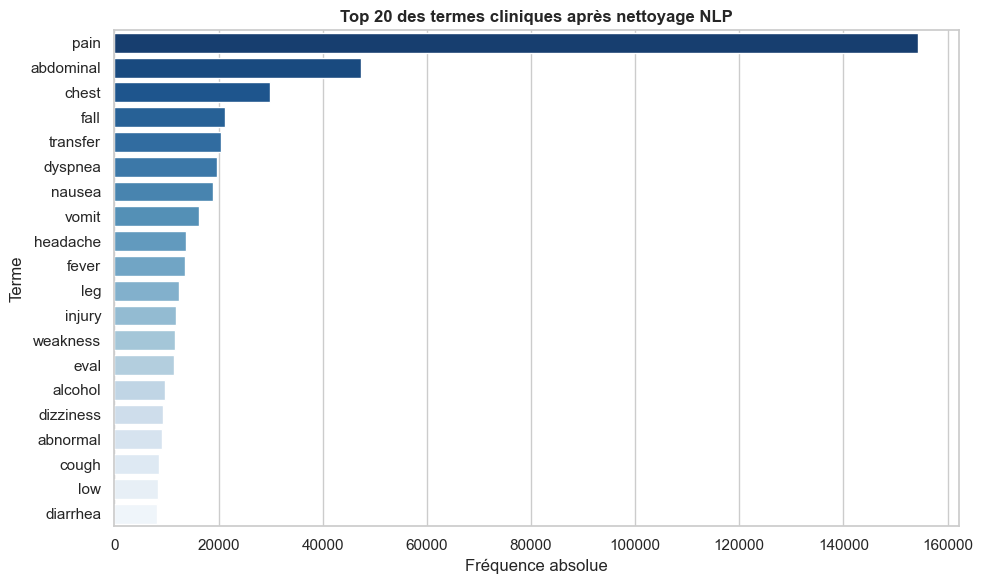

Top 10 des termes : [('pain', 154410), ('abdominal', 47382), ('chest', 29809), ('fall', 21275), ('transfer', 20463), ('dyspnea', 19768), ('nausea', 18987), ('vomit', 16202), ('headache', 13790), ('fever', 13644)]


In [3]:
# Top 20 des termes les plus fréquents
all_words = ' '.join(df['cleaned_complaint']).split()
word_freq  = Counter(all_words)
common_df  = pd.DataFrame(word_freq.most_common(20), columns=['Terme', 'Fréquence'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Fréquence', y='Terme', data=common_df, palette='Blues_r')
plt.title('Top 20 des termes cliniques après nettoyage NLP',
          fontsize=12, fontweight='bold')
plt.xlabel('Fréquence absolue')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_top_termes.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 des termes :', word_freq.most_common(10))

In [4]:
# Dépendance optionnelle : WordCloud 
# Le notebook continue même si wordcloud n'est pas installé.
try:
    from wordcloud import WordCloud
    WORDCLOUD_OK = True
    print("WordCloud disponible")
except ImportError:
    WORDCLOUD_OK = False
    print("WordCloud non installé, la cellule suivante ignorera le nuage de mots.")

WordCloud disponible


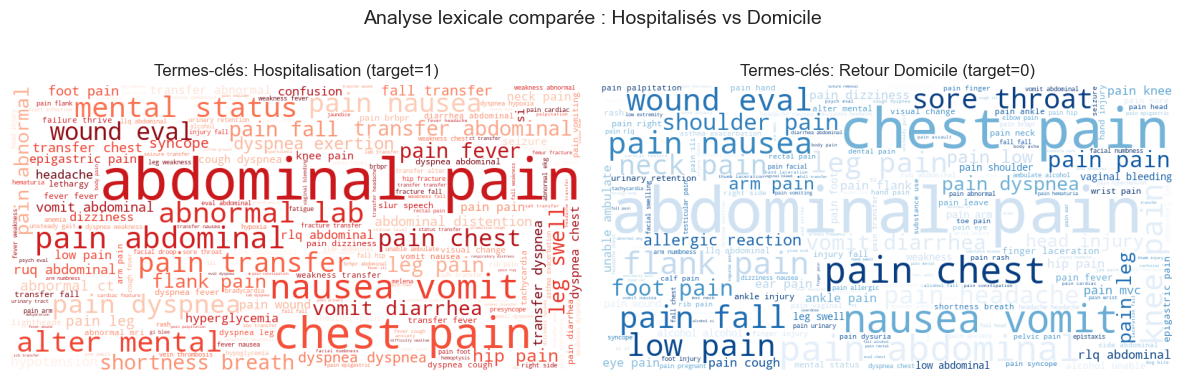

In [5]:
if WORDCLOUD_OK:
    from wordcloud import WordCloud

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

    text_hosp = ' '.join(df[df[TARGET] == 1]['cleaned_complaint'])
    wc_hosp   = WordCloud(background_color='white', colormap='Reds',
                          width=800, height=400).generate(text_hosp)
    ax1.imshow(wc_hosp)
    ax1.set_title('Termes-clés: Hospitalisation (target=1)',
                  fontsize=12, fontweight='normal')
    ax1.axis('off')

    text_home = ' '.join(df[df[TARGET] == 0]['cleaned_complaint'])
    wc_home   = WordCloud(background_color='white', colormap='Blues',
                          width=800, height=400).generate(text_home)
    ax2.imshow(wc_home)
    ax2.set_title('Termes-clés: Retour Domicile (target=0)',
                  fontsize=12, fontweight='normal')
    ax2.axis('off')

    plt.suptitle('Analyse lexicale comparée : Hospitalisés vs Domicile',
                 fontsize=14, fontweight='normal', y=0.75)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig8_wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print("wordcloud non installé  `pip install wordcloud` pour générer les nuages de mots.")

In [6]:
# Aperçu TF-IDF : top termes discriminants entre les classes
from sklearn.feature_extraction.text import TfidfVectorizer

# Bigrammes : capturent 'chest pain', 'shortness breath', etc.
tfidf_preview = TfidfVectorizer(max_features=1000, min_df=5, ngram_range=(1, 2))
X_preview     = tfidf_preview.fit_transform(df['cleaned_complaint'])

# Moyenne TF-IDF par classe
tfidf_df = pd.DataFrame(
    X_preview.toarray(),
    columns=tfidf_preview.get_feature_names_out()
)
tfidf_df[TARGET] = df[TARGET].values

diff = (
    tfidf_df[tfidf_df[TARGET] == 1].drop(columns=TARGET).mean()
    - tfidf_df[tfidf_df[TARGET] == 0].drop(columns=TARGET).mean()
)

print('=== Top 10 termes → Hospitalisation (TF-IDF moyen plus élevé) ===')
print(diff.nlargest(10).to_string())
print()
print('=== Top 10 termes → Retour domicile ===')
print(diff.nsmallest(10).to_string())

=== Top 10 termes → Hospitalisation (TF-IDF moyen plus élevé) ===
dyspnea           0.039361
transfer          0.037752
fever             0.026595
weakness          0.022999
abdominal         0.020356
abdominal pain    0.018897
abnormal          0.015090
pain transfer     0.011168
lab               0.010277
abnormal lab      0.010268

=== Top 10 termes → Retour domicile ===
pain         -0.026233
alcohol      -0.020608
headache     -0.017621
injury       -0.012609
mvc          -0.011673
laceration   -0.010735
knee         -0.008216
low          -0.008090
low pain     -0.008074
knee pain    -0.007556


---
## 4.4. Taux d’hospitalisation selon la présence du terme « transfer »

Objectif : comparer le taux d’hospitalisation (`target = 1`) entre les passages aux urgences dont le motif contient le terme exact **« transfer »** et ceux dont le motif ne contient pas ce terme.

Cette analyse permet de documenter le risque de fuite d’information associé au mot « transfer », car ce terme peut refléter une situation de transfert ou d’orientation déjà fortement liée à l’hospitalisation.

In [7]:
# Analyse descriptive : taux d'hospitalisation selon la présence du terme exact "transfer"
# Cette analyse ne modifie pas df afin de conserver cohort_nlp.csv identique à cohort_raw.csv.

transfer_pattern = r'\btransfer\b'

analysis_transfer = pd.DataFrame({
    TARGET: pd.to_numeric(df[TARGET], errors='coerce'),
    'has_transfer_term': (
        df['cleaned_complaint']
        .fillna('')
        .astype(str)
        .str.lower()
        .str.contains(transfer_pattern, regex=True)
    )
}).dropna(subset=[TARGET])

rows = []
for has_transfer, label in [
    (True, 'Motif contenant « transfer »'),
    (False, 'Motif sans « transfer »')
]:
    sub = analysis_transfer[analysis_transfer['has_transfer_term'] == has_transfer]
    n_sejours = len(sub)
    n_hospitalises = int(sub[TARGET].sum())
    taux = (n_hospitalises / n_sejours * 100) if n_sejours > 0 else np.nan
    rows.append({
        'Groupe': label,
        'Séjours ED': n_sejours,
        'Hospitalisés': n_hospitalises,
        'Non hospitalisés': n_sejours - n_hospitalises,
        'Taux hospitalisation (%)': taux
    })

transfer_hosp_summary = pd.DataFrame(rows)

# Sauvegarde du tableau descriptif
table_path = RESULT_DIR / 'tables' / 'tab2_taux_hospitalisation_transfer.csv'
transfer_hosp_summary.to_csv(table_path, index=False)

display(
    transfer_hosp_summary.style.format({
        'Séjours ED': '{:,.0f}',
        'Hospitalisés': '{:,.0f}',
        'Non hospitalisés': '{:,.0f}',
        'Taux hospitalisation (%)': '{:.1f}'
    })
)



,Groupe,Séjours ED,Hospitalisés,Non hospitalisés,Taux hospitalisation (%)
0,Motif contenant « transfer »,"20,432","16,692","3,740",81.7
1,Motif sans « transfer »,"363,487","130,123","233,364",35.8


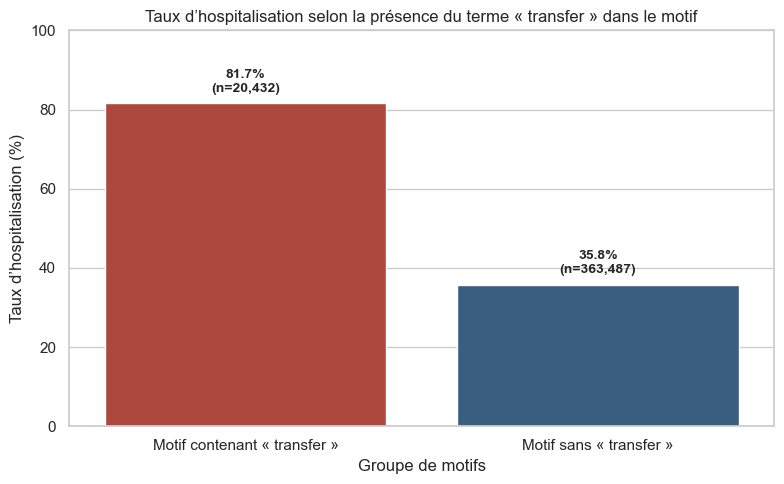

In [8]:
# Graphique : comparaison des taux d'hospitalisation
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=transfer_hosp_summary,
    x='Groupe',
    y='Taux hospitalisation (%)',
    palette=[ROUGE, BLEU]
)

plt.title('Taux d’hospitalisation selon la présence du terme « transfer » dans le motif',
          fontsize=12, fontweight='normal')
plt.xlabel('Groupe de motifs')
plt.ylabel('Taux d’hospitalisation (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)

for patch, (_, row) in zip(ax.patches, transfer_hosp_summary.iterrows()):
    height = patch.get_height()
    ax.annotate(
        f"{height:.1f}%\n(n={int(row['Séjours ED']):,})",
        xy=(patch.get_x() + patch.get_width() / 2, height),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
fig_path = FIG_DIR / 'fig9_taux_hospitalisation_transfer.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

#print('Analyse transfer sauvegardée :')
#print(f'  Tableau : {table_path}')
#print(f'  Figure  : {fig_path}')


---
## 5. Sauvegarde 

In [9]:
# Sauvegarde sous cohort_nlp.csv 
# cohort_nlp.csv = cohort_raw.csv renommé pour compatibilité avec NB03+
# Aucune transformation supplémentaire cleaned_complaint déjà présente
out_path = OUT_DIR / 'cohort_nlp.csv'
df.to_csv(out_path, index=False)

print(f'cohort_nlp.csv sauvegardé : {len(df):,} lignes × {df.shape[1]} colonnes')
#print(f'  Chemin : {out_path.resolve()}')
print()
print('=' * 55)
print('RÉSUMÉ FINAL — Notebook 02')
print('=' * 55)
print(f'Cohorte traitée       : {len(df):,} séjours')
print(f'cleaned_complaint     : déjà présente depuis NB01')
print(f'Analyses lexicales    : top termes, wordclouds, TF-IDF')
print()
print('Fichiers sauvegardés :')
#print(f'{out_path}')
print(f'figures/fig7_top_termes.png')
print(f'figures/fig8_wordclouds.png')
print(f'figures/fig9_taux_hospitalisation_transfer.png')
print(f'results/tables/tab2_taux_hospitalisation_transfer.csv')
print()
print('→ Prochaine étape : 03_Modele_avec_transfer.ipynb')


cohort_nlp.csv sauvegardé : 383,919 lignes × 38 colonnes

RÉSUMÉ FINAL — Notebook 02
Cohorte traitée       : 383,919 séjours
cleaned_complaint     : déjà présente depuis NB01
Analyses lexicales    : top termes, wordclouds, TF-IDF

Fichiers sauvegardés :
figures/fig7_top_termes.png
figures/fig8_wordclouds.png
figures/fig9_taux_hospitalisation_transfer.png
results/tables/tab2_taux_hospitalisation_transfer.csv

→ Prochaine étape : 03_Modele_avec_transfer.ipynb


In [10]:
print("NB02 terminé")


NB02 terminé
